# Merchant Fraud-Risk Modelling

This notebook builds one retrospective risk-estimation row per merchant, uses the 61 directly labelled merchants as training targets, compares five models, and scores all 4,422 merchants. The output supports merchant-ranking review; it is not proof of fraud.

In [1]:
import sys
import tempfile
from pathlib import Path

import duckdb
import pandas as pd
from IPython.display import Image, display

def find_member4_dir(start=Path.cwd().resolve()):
    for candidate in (start, *start.parents):
        direct = candidate if candidate.name == 'member4_fraud' else candidate / 'member4_fraud'
        if (direct / 'code').is_dir():
            return direct
    raise FileNotFoundError('Run this notebook from the repository or member4_fraud/code.')

MODULE_DIR = find_member4_dir()
CODE_DIR = MODULE_DIR / 'code'
REPO_ROOT = MODULE_DIR.parent
OUTPUT_DIR = Path(tempfile.gettempdir()) / 'member4_fraud_work' / 'merchant_model'
DELIVERY_DIR = MODULE_DIR / 'result'
RAW_TABLES = REPO_ROOT.parent / 'data' / 'part1' / 'tables'
if str(CODE_DIR) not in sys.path:
    sys.path.insert(0, str(CODE_DIR))
print(sys.executable)

/home/changyuan/.venvs/project2/bin/python


## 1. Modelling definition

The supplied merchant table has 114 dated scores for only 61 merchants. To match the final ranking grain and prevent the same merchant appearing in multiple splits, the dated scores are averaged to one target per merchant. `merchant_abn` and the direct fraud score are never input features.

Transaction features are calculated up to 28 February 2022. Consumer-day predictions are merged through `user_id` and aggregated into merchant exposure measures. Static merchant metadata is joined through `merchant_abn`.

## 2. Build the merchant feature tables

The scoring table contains every merchant. The training table is the 61-row labelled subset. Direct merchant fraud probability remains the target and is not used to create predictors.

In [2]:
from build_merchant_model_table import build_merchant_model_table

merchant_table_summary = build_merchant_model_table(
    repo_root=REPO_ROOT, raw_tables_root=RAW_TABLES, output_dir=OUTPUT_DIR
)
display(merchant_table_summary)

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,table_name,rows,merchants,mean_target,mean_consumer_risk_coverage
0,scoring,4422,4422,NaN,1.0
1,training,61,61,0.458362,1.0


In [3]:
TRAINING_PATH = OUTPUT_DIR / 'merchant_fraud_training_table.parquet'
SCORING_PATH = OUTPUT_DIR / 'merchant_scoring_features_2022-02-28.parquet'
training_preview = duckdb.sql(f"""
    SELECT merchant_abn, fraud_probability, target_observations,
           log_total_revenue, repeat_consumer_share, sales_growth_log,
           amount_weighted_consumer_risk, high_risk_revenue_share
    FROM read_parquet('{TRAINING_PATH.as_posix()}') LIMIT 8
""").df()
display(training_preview)

,merchant_abn,fraud_probability,target_observations,log_total_revenue,repeat_consumer_share,sales_growth_log,amount_weighted_consumer_risk,high_risk_revenue_share
0,11149063370,0.532869,3,13.640280,0.000000,0.028983,0.119650,NaN
1,11470993597,0.633773,1,9.709363,0.003817,-0.456064,0.141698,0.115412
2,11590404675,0.296078,1,13.195827,0.000000,-0.918001,0.125836,NaN
3,14530561097,0.808005,1,14.102164,0.000000,-0.060632,0.147236,0.025722
4,14827550074,0.420006,4,15.173349,0.012195,-0.225597,0.131151,0.022982
5,15043504837,0.369854,3,14.473169,0.000000,0.625099,0.131885,NaN
6,15157368385,0.642774,1,9.860422,0.000000,-0.828680,0.156262,0.075700
7,18158387243,0.290297,2,15.496777,0.180361,0.055577,0.143478,0.088491


## 3. New merged feature groups

**Merchant activity:** revenue, order value, consumer count, repeat share, recency, 30/90-day activity, growth, stability and high-value share.

**Consumer-risk exposure:** transaction-weighted risk, amount-weighted risk, unique-consumer mean risk, high-risk transaction/revenue share and coverage.

**Static merchant metadata:** take rate is retained. High-cardinality names, ABNs, categories and external demographics are excluded from this first model because 61 labels cannot support many additional parameters.

## 4. Validation and overfitting controls

- One row per merchant prevents repeated dates for the same merchant leaking across splits.
- 48 merchants form the model-selection pool; 13 stratified merchants are held out until the end.
- Hyperparameters are compared with repeated five-fold CV (5 folds × 10 repeats) on the 48 training merchants.
- Imputation and scaling are fitted inside each fold.
- Selection uses mean CV MAE, with CV RMSE as tie-breaker.
- Trees are shallow/regularized and KNN uses limited neighbour choices.
- The independent test set is evaluated only after every model form is fixed.

In [4]:
from train_merchant_models import MODEL_FEATURES, run_merchant_model_experiment

merchant_model_comparison = run_merchant_model_experiment(
    repo_root=REPO_ROOT, output_dir=OUTPUT_DIR
)
display(merchant_model_comparison)

,model,selected_by_cv,best_parameters,cv_mae_mean,cv_mae_std,cv_rmse_mean,cv_r2_mean,cv_spearman_mean,train_mae,test_mae,test_rmse,test_r2,test_spearman,test_minus_train_mae
0,XGBoost,True,"{""colsample_bytree"": 0.8, ""learning_rate"": 0.0...",0.111003,0.034204,0.152653,0.161231,0.519986,4.730439e-02,0.112490,0.209038,0.120033,0.439560,0.065185
1,KNN,False,"{""n_neighbors"": 5, ""p"": 2, ""weights"": ""distance""}",0.111090,0.037566,0.159588,0.092799,0.543196,2.842398e-09,0.121683,0.192787,0.251537,0.395604,0.121683
2,Random Forest,False,"{""max_depth"": 4, ""max_features"": 0.7, ""min_sam...",0.118292,0.033175,0.154994,0.153769,0.475472,6.915306e-02,0.116270,0.197908,0.211247,0.379121,0.047117
3,Linear Regression,False,"{""fit_intercept"": true}",0.128836,0.059858,0.169444,-0.092192,0.608620,6.371036e-02,0.156350,0.217120,0.050680,0.406593,0.092640
4,Mean Baseline,False,{},0.177915,0.024313,0.196363,-0.306449,0.000000,1.732237e-01,0.191785,0.222902,-0.000559,0.000000,0.018562


In [5]:
split_summary = pd.read_csv(OUTPUT_DIR / 'merchant_data_split_summary.csv')
diagnostics = pd.read_csv(OUTPUT_DIR / 'merchant_feature_diagnostics.csv')
high_correlations = pd.read_csv(OUTPUT_DIR / 'merchant_high_correlation_pairs.csv')
vif = pd.read_csv(OUTPUT_DIR / 'merchant_vif.csv')
display(split_summary, diagnostics.sort_values('target_spearman', key=abs, ascending=False),
        high_correlations.head(20), vif.head(20))

,split,merchants,mean_target,min_target,max_target
0,train_for_cv,48,0.457239,0.182109,0.910961
1,held_out_test,13,0.462507,0.277933,0.941347


,feature,missing_rate,unique_values,standard_deviation,target_pearson,target_spearman
0,log_total_revenue,0.000000,61,1.978067,-0.522997,-0.548262
12,transaction_value_cv,0.000000,60,0.222925,0.449505,0.467569
7,log_sales_90d,0.000000,60,2.923363,-0.196122,-0.463127
3,repeat_consumer_share,0.000000,34,0.184278,-0.378248,-0.335892
2,unique_consumers,0.000000,58,5914.369059,-0.408695,-0.222202
4,active_days,0.000000,41,142.347286,-0.275621,-0.207816
6,order_count_90d,0.000000,49,3271.881380,-0.336271,-0.207291
9,unique_consumers_90d,0.000000,49,2543.099140,-0.361008,-0.207291
1,avg_transaction_value,0.000000,61,11432.362769,-0.201395,-0.179511
16,merchant_take_rate_pct,0.213115,43,1.710879,-0.164761,-0.131640


,feature_1,feature_2,correlation,absolute_correlation
0,repeat_consumer_share,unique_consumers_90d,0.997084,0.997084
1,order_count_90d,unique_consumers_90d,0.994916,0.994916
2,unique_consumers,repeat_consumer_share,0.985576,0.985576
3,repeat_consumer_share,order_count_90d,0.984757,0.984757
4,unique_consumers,unique_consumers_90d,0.971563,0.971563
5,amount_weighted_consumer_risk,unique_consumer_mean_risk,0.943266,0.943266
6,unique_consumers,order_count_90d,0.943087,0.943087


,feature,vif
0,unique_consumers_90d,15423.741718
1,order_count_90d,6277.734994
2,repeat_consumer_share,1950.286238
3,unique_consumers,1486.117906
4,log_sales_90d,282.078730
5,log_total_revenue,157.567499
6,avg_transaction_value,104.521470
7,avg_order_value_90d,53.651333
8,high_value_transaction_ratio_90d,25.499687
9,unique_consumer_mean_risk,13.342857


## 5. Model 1 — Mean baseline

In [6]:
tuning = pd.read_csv(OUTPUT_DIR / 'merchant_model_tuning_results.csv')
forms = pd.read_csv(OUTPUT_DIR / 'merchant_best_model_forms.csv')
display(tuning.query("model == 'Mean Baseline'"), forms.query("model == 'Mean Baseline'"))

,model,candidate_id,parameters,cv_folds,cv_mae_mean,cv_mae_std,cv_rmse_mean,cv_rmse_std,cv_r2_mean,cv_spearman_mean,fit_seconds
9,Mean Baseline,mean_baseline_01,{},50,0.177915,0.024313,0.196363,0.027969,-0.306449,0.0,0.484267


,model,preprocessing,best_form,best_parameters,saved_model
0,Mean Baseline,Training-fold median target,Constant mean prediction.,{},models/mean_baseline.joblib


## 6. Model 2 — K-nearest neighbours

The train-to-test error gap is reviewed because distance weighting can memorize a 48-merchant training set.

In [7]:
display(tuning.query("model == 'KNN'").sort_values(['cv_mae_mean', 'cv_rmse_mean']),
        forms.query("model == 'KNN'"))

,model,candidate_id,parameters,cv_folds,cv_mae_mean,cv_mae_std,cv_rmse_mean,cv_rmse_std,cv_r2_mean,cv_spearman_mean,fit_seconds
0,KNN,knn_04,"{""n_neighbors"": 5, ""p"": 2, ""weights"": ""distance""}",50,0.111090,0.037566,0.159588,0.045894,0.092799,0.543196,1.032067
1,KNN,knn_03,"{""n_neighbors"": 5, ""p"": 2, ""weights"": ""uniform""}",50,0.111403,0.037952,0.161925,0.045434,0.049732,0.548043,0.731763
2,KNN,knn_01,"{""n_neighbors"": 3, ""p"": 2, ""weights"": ""uniform""}",50,0.115023,0.037533,0.165936,0.046171,0.052786,0.531829,0.789636
3,KNN,knn_02,"{""n_neighbors"": 3, ""p"": 2, ""weights"": ""distance""}",50,0.115236,0.037796,0.163299,0.047256,0.091218,0.544287,0.879197
4,KNN,knn_06,"{""n_neighbors"": 8, ""p"": 2, ""weights"": ""distance""}",50,0.115623,0.035552,0.159258,0.043029,0.069729,0.546621,0.950534
5,KNN,knn_05,"{""n_neighbors"": 8, ""p"": 2, ""weights"": ""uniform""}",50,0.118339,0.034929,0.160810,0.041551,0.043668,0.542157,0.904725
6,KNN,knn_08,"{""n_neighbors"": 12, ""p"": 2, ""weights"": ""distan...",50,0.122562,0.036482,0.160879,0.043419,0.053853,0.515437,0.937552
7,KNN,knn_07,"{""n_neighbors"": 12, ""p"": 2, ""weights"": ""uniform""}",50,0.133571,0.034753,0.166848,0.040491,-0.015429,0.480377,0.875008


,model,preprocessing,best_form,best_parameters,saved_model
1,KNN,Median imputation + StandardScaler inside each...,Nearest-neighbour regression.,"{""n_neighbors"": 5, ""p"": 2, ""weights"": ""distance""}",models/knn.joblib


## 7. Model 3 — Linear regression

Coefficients are interpretable associations only; high VIF values warn where correlated merchant features make individual coefficients unstable.

In [8]:
linear_coefficients = pd.read_csv(OUTPUT_DIR / 'merchant_linear_regression_coefficients.csv')
display(tuning.query("model == 'Linear Regression'"),
        forms.query("model == 'Linear Regression'"), linear_coefficients.head(15))

,model,candidate_id,parameters,cv_folds,cv_mae_mean,cv_mae_std,cv_rmse_mean,cv_rmse_std,cv_r2_mean,cv_spearman_mean,fit_seconds
8,Linear Regression,linear_regression_01,"{""fit_intercept"": true}",50,0.128836,0.059858,0.169444,0.078654,-0.092192,0.60862,0.607939


,model,preprocessing,best_form,best_parameters,saved_model
2,Linear Regression,Median imputation + StandardScaler inside each...,Ordinary linear regression on standardized fea...,"{""fit_intercept"": true}",models/linear_regression.joblib


,feature,standardized_coefficient,absolute_coefficient,intercept
0,log_sales_90d,0.691046,0.691046,0.458362
1,unique_consumers_90d,0.660897,0.660897,0.458362
2,log_total_revenue,-0.559041,0.559041,0.458362
3,avg_order_value_90d,-0.377923,0.377923,0.458362
4,repeat_consumer_share,-0.368165,0.368165,0.458362
5,avg_transaction_value,0.355540,0.355540,0.458362
6,order_count_90d,-0.271584,0.271584,0.458362
7,unique_consumer_mean_risk,0.199665,0.199665,0.458362
8,amount_weighted_consumer_risk,-0.179040,0.179040,0.458362
9,active_days,-0.082133,0.082133,0.458362


## 8. Model 4 — Random forest

Depth and leaf size are constrained to reduce small-sample overfitting.

In [9]:
importance = pd.read_csv(OUTPUT_DIR / 'merchant_tree_feature_importance.csv')
display(tuning.query("model == 'Random Forest'").sort_values(['cv_mae_mean', 'cv_rmse_mean']),
        forms.query("model == 'Random Forest'"), importance.query("model == 'Random Forest'").head(12))

,model,candidate_id,parameters,cv_folds,cv_mae_mean,cv_mae_std,cv_rmse_mean,cv_rmse_std,cv_r2_mean,cv_spearman_mean,fit_seconds
10,Random Forest,random_forest_03,"{""max_depth"": 4, ""max_features"": 0.7, ""min_sam...",50,0.118292,0.033175,0.154994,0.041261,0.153769,0.475472,35.511460
11,Random Forest,random_forest_02,"{""max_depth"": 3, ""max_features"": 0.7, ""min_sam...",50,0.118795,0.033120,0.155420,0.041305,0.149698,0.466315,35.627165
12,Random Forest,random_forest_01,"{""max_depth"": 2, ""max_features"": 0.7, ""min_sam...",50,0.121479,0.033109,0.157553,0.042001,0.130919,0.439568,35.470631
13,Random Forest,random_forest_04,"{""max_depth"": 3, ""max_features"": 1.0, ""min_sam...",50,0.125331,0.032569,0.166085,0.040956,0.000120,0.408014,35.362315
14,Random Forest,random_forest_05,"{""max_depth"": 4, ""max_features"": 1.0, ""min_sam...",50,0.125331,0.032569,0.166085,0.040956,0.000120,0.408014,35.037978
15,Random Forest,random_forest_06,"{""max_depth"": null, ""max_features"": 0.7, ""min_...",50,0.136005,0.028417,0.170385,0.037917,-0.059540,0.409675,34.589922


,model,preprocessing,best_form,best_parameters,saved_model
3,Random Forest,Training-fold median imputation,Constrained regression-tree ensemble.,"{""max_depth"": 4, ""max_features"": 0.7, ""min_sam...",models/random_forest.joblib


,model,feature,importance
0,Random Forest,log_total_revenue,0.236595
1,Random Forest,log_sales_90d,0.142923
2,Random Forest,transaction_value_cv,0.141595
3,Random Forest,unique_consumer_mean_risk,0.055839
4,Random Forest,order_count_90d,0.051893
5,Random Forest,avg_transaction_value,0.048780
6,Random Forest,unique_consumers_90d,0.047315
7,Random Forest,unique_consumers,0.045868
8,Random Forest,amount_weighted_consumer_risk,0.039546
9,Random Forest,days_since_last_transaction,0.036919


## 9. Model 5 — XGBoost

Only shallow, strongly regularized candidates are considered because the labelled sample is small.

In [10]:
display(tuning.query("model == 'XGBoost'").sort_values(['cv_mae_mean', 'cv_rmse_mean']),
        forms.query("model == 'XGBoost'"), importance.query("model == 'XGBoost'").head(12))

,model,candidate_id,parameters,cv_folds,cv_mae_mean,cv_mae_std,cv_rmse_mean,cv_rmse_std,cv_r2_mean,cv_spearman_mean,fit_seconds
16,XGBoost,xgboost_04,"{""colsample_bytree"": 0.8, ""learning_rate"": 0.0...",50,0.111003,0.034204,0.152653,0.043772,0.161231,0.519986,2.003648
17,XGBoost,xgboost_03,"{""colsample_bytree"": 0.8, ""learning_rate"": 0.0...",50,0.118886,0.031917,0.154062,0.039794,0.156420,0.482173,1.420719
18,XGBoost,xgboost_06,"{""colsample_bytree"": 0.8, ""learning_rate"": 0.0...",50,0.119730,0.036684,0.160299,0.043399,0.088264,0.504972,2.044646
19,XGBoost,xgboost_05,"{""colsample_bytree"": 0.8, ""learning_rate"": 0.0...",50,0.120165,0.034984,0.161389,0.041411,0.064068,0.469844,1.476041
20,XGBoost,xgboost_02,"{""colsample_bytree"": 0.8, ""learning_rate"": 0.0...",50,0.124127,0.033376,0.161684,0.042535,0.064007,0.448586,1.859513
21,XGBoost,xgboost_01,"{""colsample_bytree"": 0.8, ""learning_rate"": 0.0...",50,0.141760,0.028291,0.171557,0.036352,-0.051260,0.397705,1.307087


,model,preprocessing,best_form,best_parameters,saved_model
4,XGBoost,Training-fold median imputation,Regularized shallow boosted trees.,"{""colsample_bytree"": 0.8, ""learning_rate"": 0.0...",models/xgboost.joblib


,model,feature,importance
17,XGBoost,log_total_revenue,0.122019
18,XGBoost,unique_consumers_90d,0.120403
19,XGBoost,log_sales_90d,0.104494
20,XGBoost,transaction_value_cv,0.089223
21,XGBoost,order_count_90d,0.087608
22,XGBoost,repeat_consumer_share,0.075134
23,XGBoost,unique_consumers,0.059071
24,XGBoost,unique_consumer_mean_risk,0.056698
25,XGBoost,active_days,0.053051
26,XGBoost,avg_transaction_value,0.046398


## 10. Final model and outputs

The selected model is determined only by repeated-CV performance. The holdout result is reported as an independent check and is not used to switch models. Because only 61 merchants are labelled, uncertainty and prediction sensitivity must remain visible in the final ranking.

,model,selected_by_cv,best_parameters,cv_mae_mean,cv_mae_std,cv_rmse_mean,cv_r2_mean,cv_spearman_mean,train_mae,test_mae,test_rmse,test_r2,test_spearman,test_minus_train_mae
0,XGBoost,True,"{""colsample_bytree"": 0.8, ""learning_rate"": 0.0...",0.111003,0.034204,0.152653,0.161231,0.519986,4.730439e-02,0.112490,0.209038,0.120033,0.439560,0.065185
1,KNN,False,"{""n_neighbors"": 5, ""p"": 2, ""weights"": ""distance""}",0.111090,0.037566,0.159588,0.092799,0.543196,2.842398e-09,0.121683,0.192787,0.251537,0.395604,0.121683
2,Random Forest,False,"{""max_depth"": 4, ""max_features"": 0.7, ""min_sam...",0.118292,0.033175,0.154994,0.153769,0.475472,6.915306e-02,0.116270,0.197908,0.211247,0.379121,0.047117
3,Linear Regression,False,"{""fit_intercept"": true}",0.128836,0.059858,0.169444,-0.092192,0.608620,6.371036e-02,0.156350,0.217120,0.050680,0.406593,0.092640
4,Mean Baseline,False,{},0.177915,0.024313,0.196363,-0.306449,0.000000,1.732237e-01,0.191785,0.222902,-0.000559,0.000000,0.018562


,model,preprocessing,best_form,best_parameters,saved_model
0,Mean Baseline,Training-fold median target,Constant mean prediction.,{},models/mean_baseline.joblib
1,KNN,Median imputation + StandardScaler inside each...,Nearest-neighbour regression.,"{""n_neighbors"": 5, ""p"": 2, ""weights"": ""distance""}",models/knn.joblib
2,Linear Regression,Median imputation + StandardScaler inside each...,Ordinary linear regression on standardized fea...,"{""fit_intercept"": true}",models/linear_regression.joblib
3,Random Forest,Training-fold median imputation,Constrained regression-tree ensemble.,"{""max_depth"": 4, ""max_features"": 0.7, ""min_sam...",models/random_forest.joblib
4,XGBoost,Training-fold median imputation,Regularized shallow boosted trees.,"{""colsample_bytree"": 0.8, ""learning_rate"": 0.0...",models/xgboost.joblib


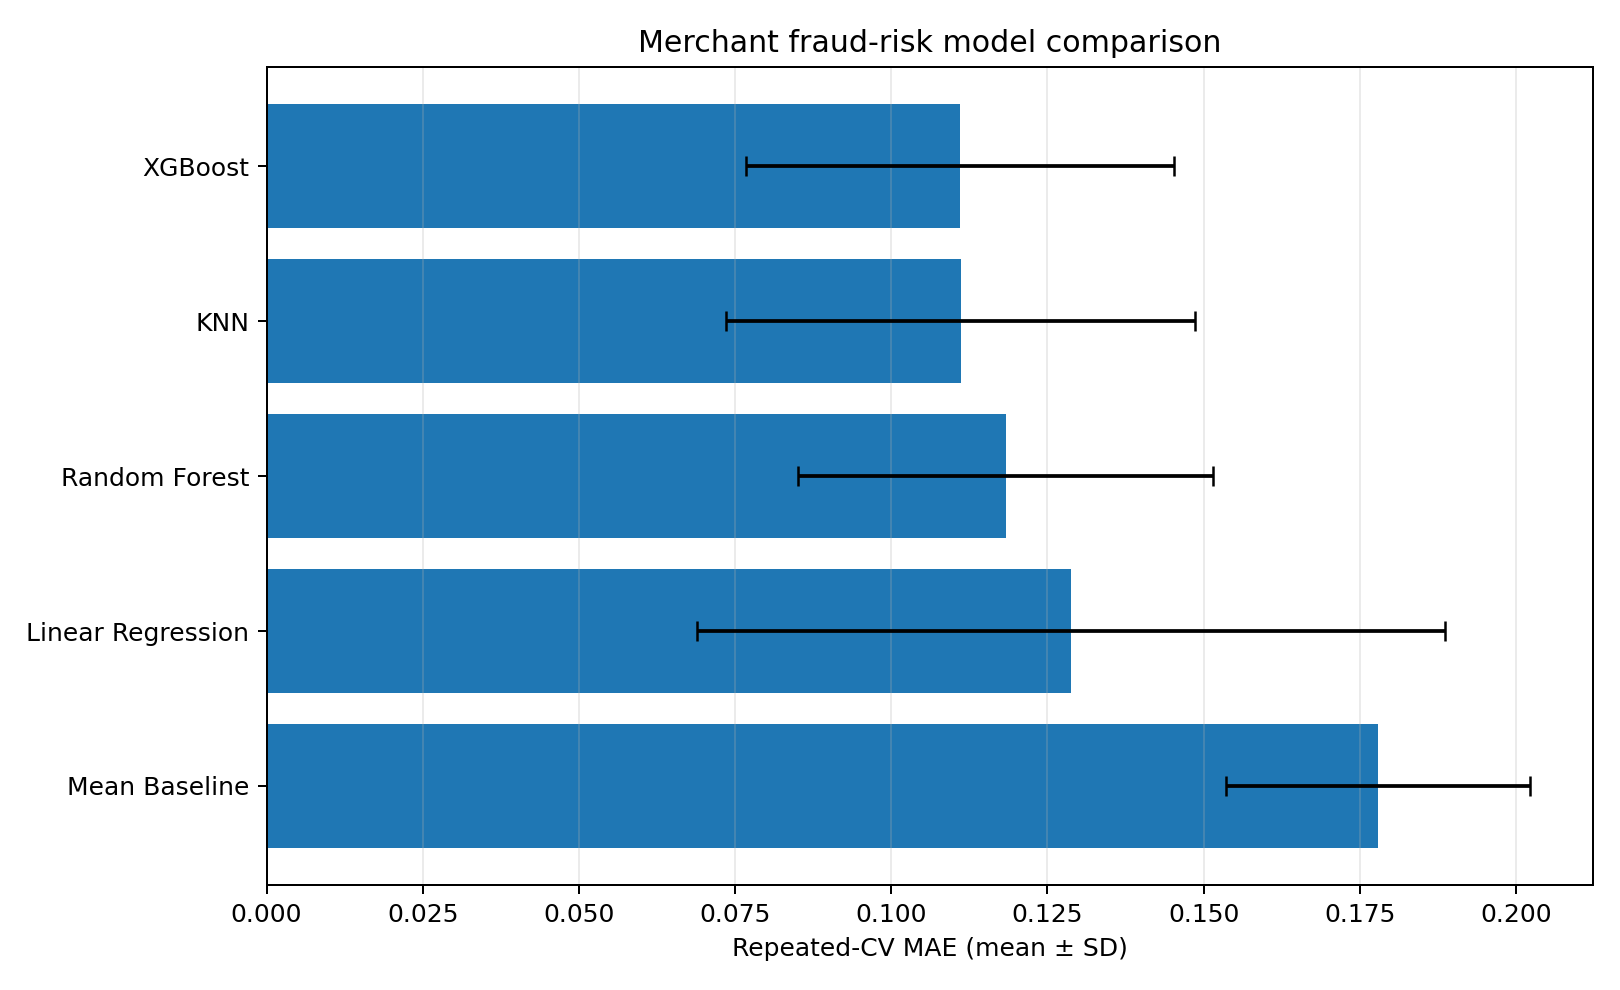

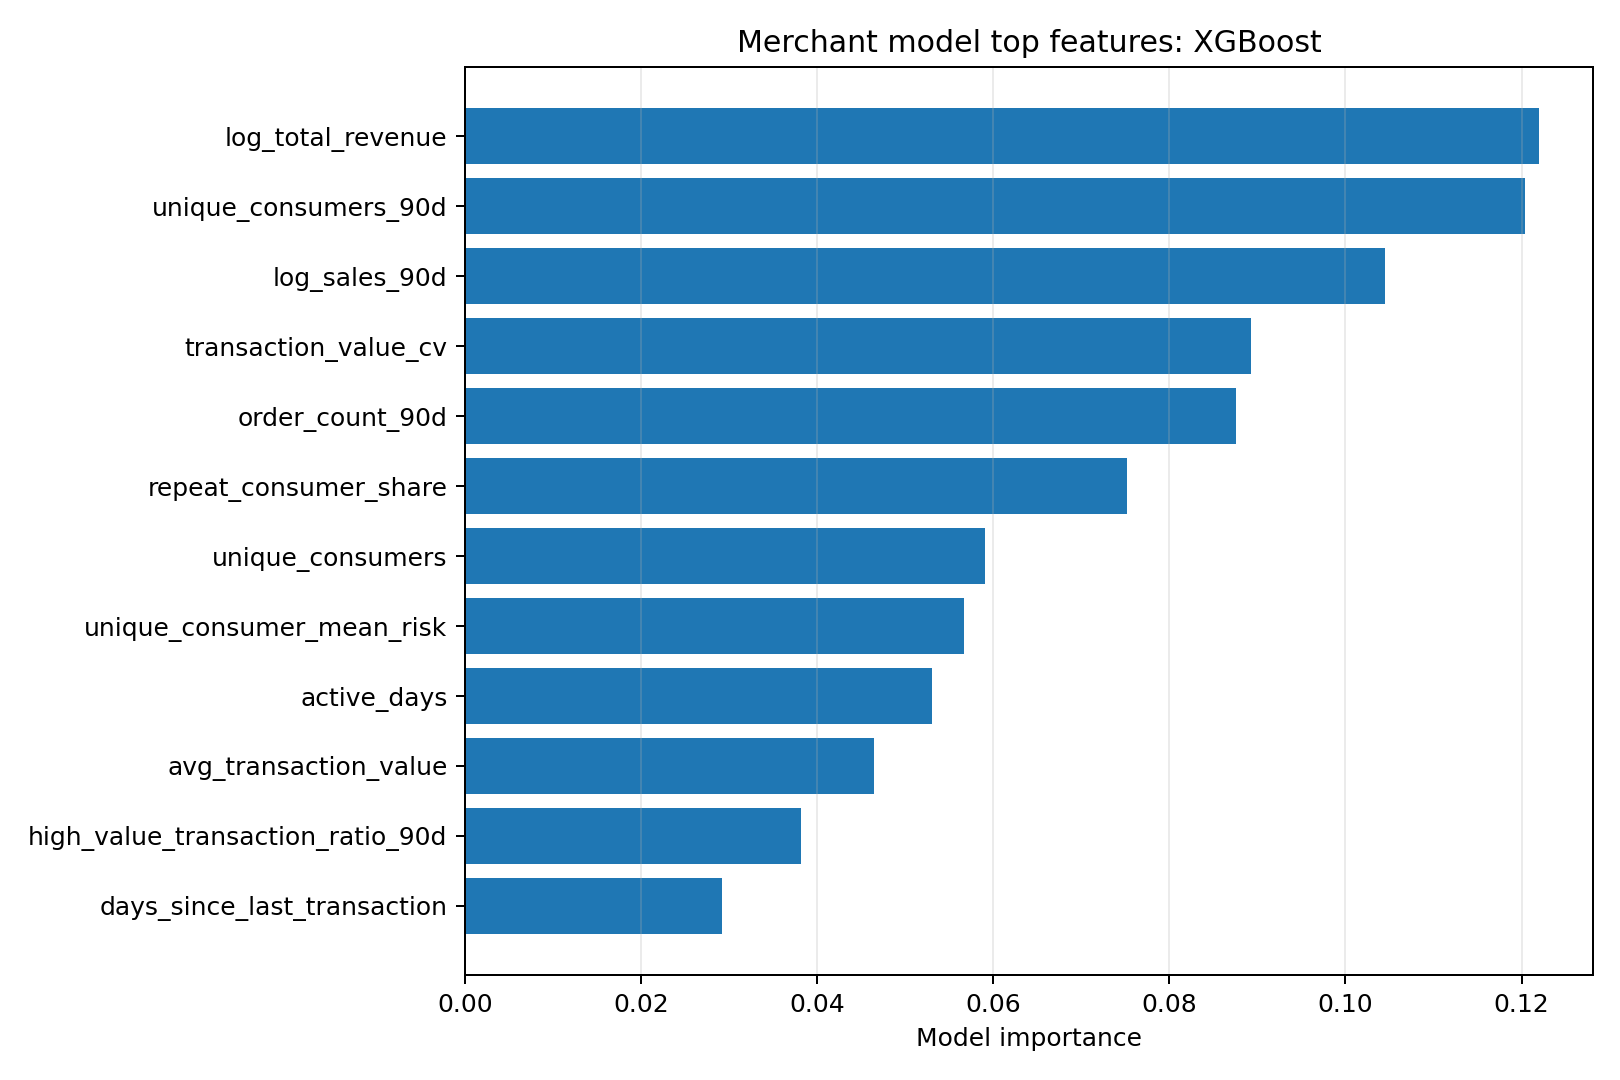

In [11]:
comparison = pd.read_csv(OUTPUT_DIR / 'merchant_model_comparison.csv')
display(comparison, forms)
display(Image(filename=str(OUTPUT_DIR / 'figures' / 'merchant_model_comparison.png')))
selected_name = comparison.loc[comparison.selected_by_cv, 'model'].iloc[0]
if selected_name in {'Random Forest', 'XGBoost'}:
    display(Image(filename=str(OUTPUT_DIR / 'figures' / 'merchant_selected_model_feature_importance.png')))

In [12]:
prediction_path = OUTPUT_DIR / 'merchant_fraud_predictions_all.parquet'
prediction_audit = duckdb.sql(f"""
    SELECT count(*) AS merchants,
           sum(merchant_fraud_label_available::INTEGER) AS directly_labelled_merchants,
           min(predicted_merchant_fraud_probability) AS min_prediction,
           avg(predicted_merchant_fraud_probability) AS mean_prediction,
           max(predicted_merchant_fraud_probability) AS max_prediction,
           count(DISTINCT predicted_merchant_fraud_probability) AS distinct_predictions
    FROM read_parquet('{prediction_path.as_posix()}')
""").df()
display(prediction_audit)
delivery_files = [
    'merchant_best_model_forms.csv',
    'merchant_data_split_summary.csv',
    'merchant_fraud_predictions_all.csv',
    'merchant_model_comparison.csv',
    'merchant_model_tuning_results.csv',
    'merchant_tree_feature_importance.csv',
]
DELIVERY_DIR.mkdir(parents=True, exist_ok=True)
for filename in delivery_files:
    source = OUTPUT_DIR / filename
    target = DELIVERY_DIR / filename
    target.write_bytes(source.read_bytes())
print('Delivered merchant CSV files to:', DELIVERY_DIR)

,merchants,directly_labelled_merchants,min_prediction,mean_prediction,max_prediction,distinct_predictions
0,4422,61.0,0.258153,0.544685,0.784451,4350


Delivered merchant CSV files to: member4_fraud/result


## 11. Responsible interpretation

The selected score is a model estimate learned from only 61 directly labelled merchants. It must be combined with revenue, growth, repeat behaviour and coverage in the final ranking rather than used as an automatic exclusion rule. Consumer and merchant fraud scores are supplied probabilities, not confirmed events.